# Version 1: ESCO Occupation-Skill Matrix Tables

#### Advantages
- Working at the skill-group level (n=290) as opposed to with individual ESCO skills (n=13485) is more interpretable

#### Disadvantages
- Simulation of upskilling not straightforward: skill vectors are continuous, not binary. up/reskilling would entail shifting the relative importance of skills within an occupation.

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

from mapping_career_causeways.compare_nodes_utils import find_closest

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=1.5)

Define paths to lfs data

In [2]:
# project directory
abspath = os.path.abspath("")
project_dir = str(Path(abspath).parents[0])

# sub-directories
data_raw = os.path.join(project_dir, "data", "raw")
data_interim = os.path.join(project_dir, "data", "interim")
data_external = os.path.join(project_dir, "data", "external")
data_processed = os.path.join(project_dir, "data", "processed")

fpath_lfs = r"C:\eurostat_data"
main_data = r"Yearly Data\YearlyFiles_83_2019\_YearlyFiles"

Read geodata with NUTS regions

In [3]:
gdf = gpd.read_file(
    os.path.join(
        data_external,
        "geodata",
        "NUTS_RG_03M_2021_4326_LEVL_2",
        "NUTS_RG_03M_2021_4326_LEVL_2.shp",
    )
)

Zoom in on Germany

In [4]:
df_de = pd.read_csv(
    os.path.join(data_processed, "lfs", "eu_lfs_merged_allyears_de.csv")
)

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_6932\2142021092.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_de = pd.read_csv(os.path.join(data_processed, "lfs", "eu_lfs_merged_allyears_de.csv"))


## Occupation distance analysis

Notes
- occupation distance measure at ISCO 3D level (todo: aggregate from ESCO)
- additional covariates: income deciles, skill level as proxy for education, ...
- analysis will be slightly different than the Nesta approach

Questions
- how to calculate average skill profile of 3D groups from Nesta matrix?
- wouldnt i need to start from the occ-skills matrix?

Decision
- use ESCO Skill-Occupation Matrix Tables for the start
- directly maps from 125 ISCO 3D occupations to 290 ESCO skill groups

In [5]:
occ_skill_table = pd.read_excel(
    os.path.join(data_raw, "esco", "en_Skills_Occupations Matrix Tables.xlsx"),
    sheet_name="Matrix 3.3",
)

# row multiindex
occ_skill_table = occ_skill_table.set_index(["Unnamed: 0", "Unnamed: 1"])
occ_skill_table.index.names = ["occ_uri", "occ"]

# column multiindex
col_indizes = [
    occ_skill_table.columns.values.tolist(),
    occ_skill_table.iloc[0, :].values.tolist(),
]
tuples = list(zip(*col_indizes))
col_index = pd.MultiIndex.from_tuples(tuples, names=["skill_uri", "skill"])
occ_skill_table.columns = col_index
occ_skill_table = occ_skill_table.iloc[1:, :]
occ_skill_table = occ_skill_table.astype(float)

# convert from fractions to percentages to avoid multiplication of values below 0
occ_skill_table *= 100

assert np.allclose(occ_skill_table.sum(axis=1).values, 100)

Create occupation group similarity matrix from occ-skills matrix

In [6]:
occ_sims = np.matmul(occ_skill_table.values, occ_skill_table.values.transpose())
df_occ_sims = pd.DataFrame(
    index=occ_skill_table.index, columns=occ_skill_table.index, data=occ_sims
)

Text(0.5, 0, 'Target ISCO 3D groups')

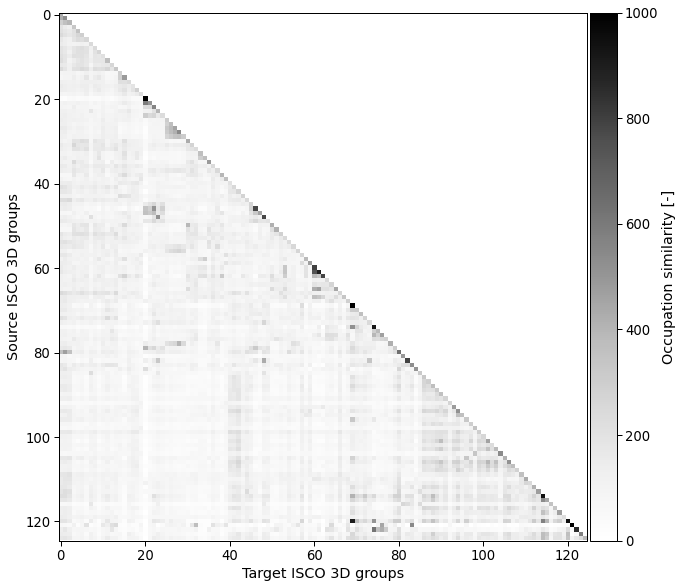

In [7]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(np.tril(df_occ_sims.values), cmap="Greys", vmax=1000)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, orientation="vertical", label="Occupation similarity [-]")
ax.set_ylabel("Source ISCO 3D groups")
ax.set_xlabel("Target ISCO 3D groups")

Implement searching for closest occupation groups

In [8]:
df_occs = df_occ_sims.index.to_frame().reset_index(drop=True)
df_occs

,occ_uri,occ
0,http://data.europa.eu/esco/isco/C011,Commissioned armed forces officers
1,http://data.europa.eu/esco/isco/C021,Non-commissioned armed forces officers
2,http://data.europa.eu/esco/isco/C031,"Armed forces occupations, other ranks"
3,http://data.europa.eu/esco/isco/C111,Legislators and senior officials
4,http://data.europa.eu/esco/isco/C112,Managing directors and chief executives
...,...,...
120,http://data.europa.eu/esco/isco/C941,Food preparation assistants
121,http://data.europa.eu/esco/isco/C951,Street and related service workers
122,http://data.europa.eu/esco/isco/C952,Street vendors (excluding food)
123,http://data.europa.eu/esco/isco/C961,Refuse workers


In [9]:
similarity_matrix = df_occ_sims.copy().values
np.fill_diagonal(similarity_matrix, 0)

i = 100
print(df_occs.iloc[i, 1])

find_closest(i=i, similarity_matrix=similarity_matrix, df=df_occs)

Mining and mineral processing plant operators


,occ_uri,occ,similarity
106,http://data.europa.eu/esco/isco/C817,Wood processing and papermaking plant operators,262.364674
101,http://data.europa.eu/esco/isco/C812,Metal processing and finishing plant operators,229.682637
103,http://data.europa.eu/esco/isco/C814,"Rubber, plastic and paper products machine ope...",225.067031
107,http://data.europa.eu/esco/isco/C818,Other stationary plant and machine operators,200.889199
90,http://data.europa.eu/esco/isco/C722,"Blacksmiths, toolmakers and related trades wor...",196.427252
...,...,...,...
38,http://data.europa.eu/esco/isco/C264,"Authors, journalists and linguists",34.018423
47,http://data.europa.eu/esco/isco/C323,Traditional and complementary medicine associa...,32.848852
20,http://data.europa.eu/esco/isco/C221,Medical doctors,19.904364
121,http://data.europa.eu/esco/isco/C951,Street and related service workers,7.539435


#### Aggregate to ISCO 3-digit level

In [10]:
agg_dict = {
    "COEFF": np.sum,
    "AGE": np.mean,
    "INCDECIL": np.median,
    "is_green": np.mean,
    "is_brown": np.mean,
    "is_neutral": np.mean,
    "annual_earnings_2016": np.mean,
}
isco3d_avg_de = df_de.groupby("ISCO3D_label").aggregate(agg_dict)

# define the GBN category of an ISCO 3D group as the one with the highest fraction (of ESCO occupations)
isco3d_avg_de["category"] = isco3d_avg_de[
    ["is_brown", "is_green", "is_neutral"]
].idxmax(axis=1)

# merge to df
df_occs_metadata = pd.merge(
    df_occs,
    isco3d_avg_de.reset_index(),
    left_on="occ",
    right_on="ISCO3D_label",
    how="left",
).drop(["ISCO3D_label", "is_green", "is_brown", "is_neutral"], axis=1)

Base the quantile on the respective quantiles of the viable/highly viable transition categories in the Kanders matrix
- Viable: 96th percentile
- Highly viable: 99th percentile

Viable/highly viable transitions
- Mining and mineral processing plant operators: 0
- Manufacturing, mining, construction, and distr: 2
- Mining, manufacturing and construction supervi: 1
- Mining and construction labourers: 8

In [11]:
q_viable = np.percentile(df_occ_sims.values.flatten(), q=96)
q_highly_viable = np.percentile(df_occ_sims.values.flatten(), q=99)

print(q_viable, q_highly_viable)

222.81179801973278 352.2193260713949


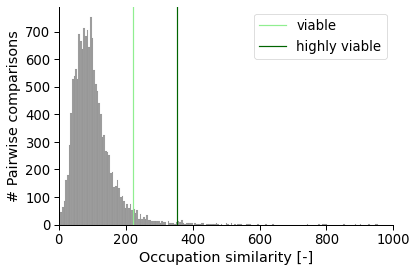

In [12]:
ax = sns.histplot(df_occ_sims.values.flatten(), color="grey")
ax.set_xlim(0, 1000)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Occupation similarity [-]")
plt.legend()
sns.despine()

Occupation similarity matrix classified viable/highly viable

In [13]:
similarity_matrix_classified = df_occ_sims.copy().values
np.fill_diagonal(similarity_matrix_classified, 0)

similarity_matrix_classified[similarity_matrix_classified < q_viable] = 0
similarity_matrix_classified[
    (similarity_matrix_classified >= q_viable)
    & (similarity_matrix_classified < q_highly_viable)
] = 1
similarity_matrix_classified[similarity_matrix_classified >= q_highly_viable] = 2

Text(0.5, 0, 'Target ISCO 3D groups')

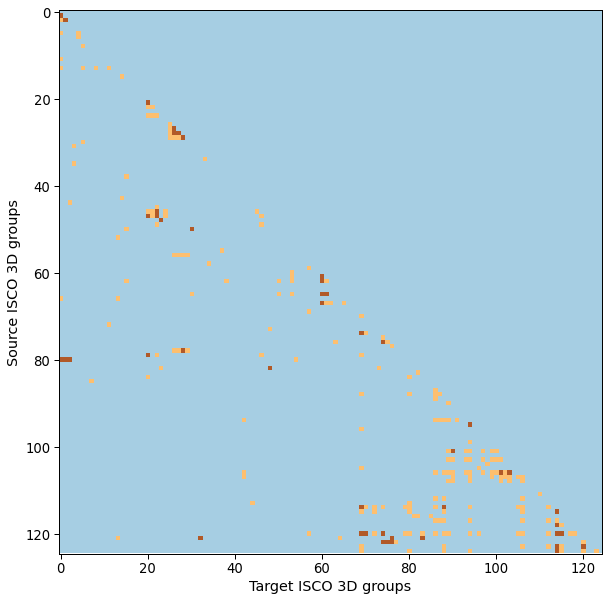

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(np.tril(similarity_matrix_classified), cmap="Paired")

ax.set_ylabel("Source ISCO 3D groups")
ax.set_xlabel("Target ISCO 3D groups")

Zoom in on coal-related jobs

In [15]:
df_de_merged_mining = df_de.loc[df_de.mining == True]

Analyse number of viable transitions

In [16]:
transition_number_data = []

for i, search_obs in df_de_merged_mining.iterrows():

    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

    target_occs = find_closest(
        i=idx, similarity_matrix=similarity_matrix, df=df_occs_metadata
    )

    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[
        target_occs_filtered.category != "is_brown"
    ]
    target_occs_filtered = target_occs_filtered.dropna()

    # earnings delta to next closest occupation
    target = target_occs_filtered.head(1)

    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (
            target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016
        ) * search_obs.COEFF
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = (
            target_occs_filtered.shape[0] * search_obs.COEFF
        )
        search_obs["transition_viable"] = True
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs["earnings_delta_closest_switch"] = (
            search_obs.annual_earnings_2016 * (-1) * search_obs.COEFF
        )
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False

    transition_number_data.append(search_obs)

df_transition_numbers = pd.concat(transition_number_data, axis=1).T
df_transition_numbers = df_transition_numbers.infer_objects()

Calculate avg number of transitions per threatened job

In [17]:
df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
df_transition_numbers_by_nuts["n_viable_transitions_rel"] = (
    df_transition_numbers_by_nuts.n_viable_transitions_sum
    / df_transition_numbers_by_nuts.COEFF
)

Text(106.0851900775629, 0.5, 'Latitude (degrees)')

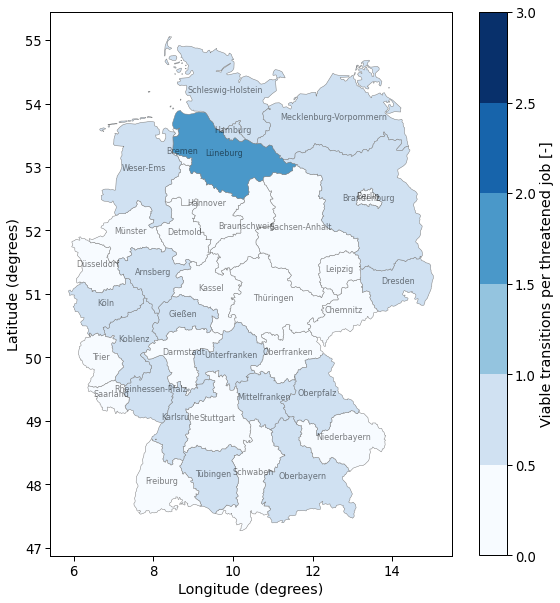

In [18]:
df_transition_numbers_by_nuts.reset_index()

gdf_transition_numbers_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left",
)

cmap = plt.get_cmap("Blues", 6)
ax = gdf_transition_numbers_by_nuts.plot(
    column="n_viable_transitions_rel",
    figsize=(10, 10),
    legend=True,
    cmap=cmap,
    vmin=0,
    vmax=3,
    legend_kwds={"label": "Viable transitions per threatened job [-]"},
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)

# ax.set_title("Mining-related employment")
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Latitude (degrees)")

#### Not sure if this makes sense...

risk = 1 / n_viable_transitions * n_at_risk_jobs

if n_viable_transitions = 0, ratio is set to 1

Text(106.0851900775629, 0.5, 'Latitude (degrees)')

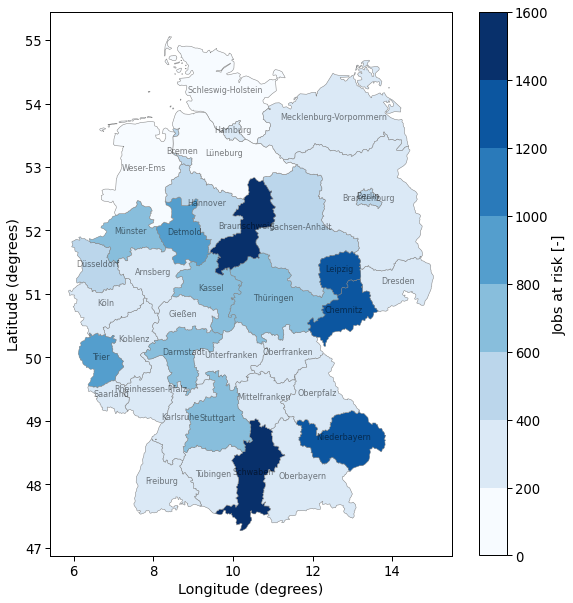

In [19]:
gdf_transition_numbers_by_nuts["risk_indicator"] = (
    1 / gdf_transition_numbers_by_nuts.n_viable_transitions
).replace([np.inf, -np.inf], 1) * gdf_transition_numbers_by_nuts.COEFF

cmap = plt.get_cmap("Blues", 8)
ax = gdf_transition_numbers_by_nuts.plot(
    column="risk_indicator",
    figsize=(10, 10),
    legend=True,
    cmap=cmap,
    vmin=0,
    vmax=1600,
    legend_kwds={"label": "Jobs at risk [-]"},
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)

# ax.set_title("Mining-related employment")
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Latitude (degrees)")

Text(106.0851900775629, 0.5, 'Latitude (degrees)')

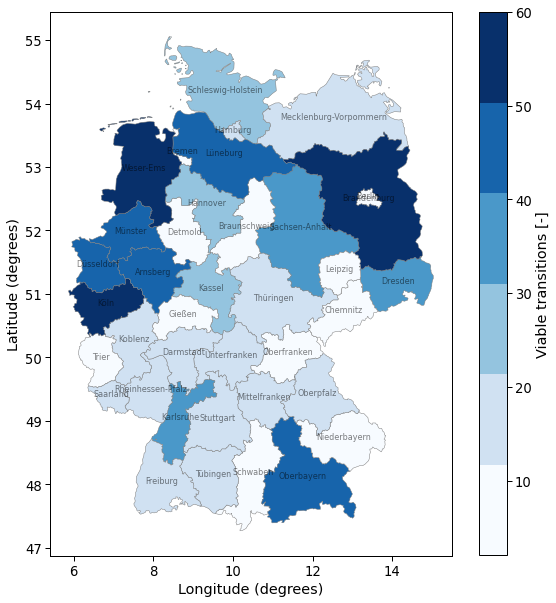

In [20]:
cmap = plt.get_cmap("Blues", 6)
ax = gdf_transition_numbers_by_nuts.plot(
    column="n_viable_transitions",
    figsize=(10, 10),
    legend=True,
    cmap=cmap,
    legend_kwds={"label": "Viable transitions [-]"},
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)

# ax.set_title("Mining-related employment")
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Latitude (degrees)")

Assumptions:
- every worker in the source occupation switches to the same target occupation

Text(106.0851900775629, 0.5, 'Latitude (degrees)')

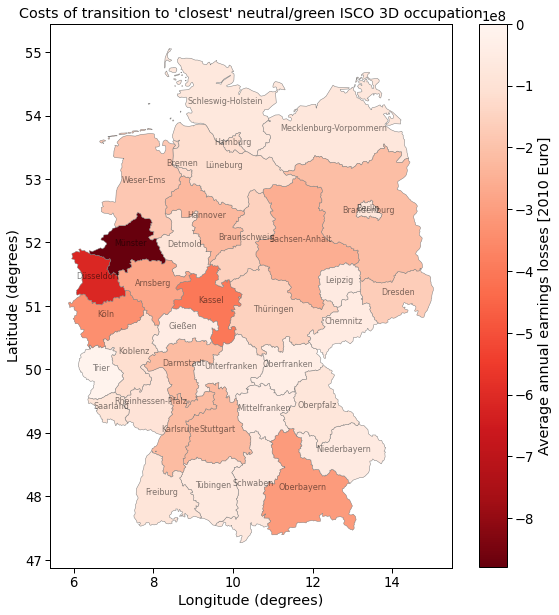

In [21]:
cmap = plt.get_cmap("Reds_r")
ax = gdf_transition_numbers_by_nuts.plot(
    column="earnings_delta_closest_switch",
    figsize=(10, 10),
    legend=True,
    vmax=0,
    cmap=cmap,
    legend_kwds={"label": "Average annual earnings losses [2010 Euro]"},
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    edgecolor="grey",
    linewidth=0.5,
)
gdf_transition_numbers_by_nuts.apply(
    lambda x: ax.annotate(
        text=x.NUTS_NAME,
        xy=x.geometry.centroid.coords[0],
        ha="center",
        alpha=0.5,
        rotation=0,
        fontsize=8,
    ),
    axis=1,
)

ax.set_title("Costs of transition to 'closest' neutral/green ISCO 3D occupation")
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Latitude (degrees)")

Annual earnings losses of 35000 workers moving out of their mining-related job into a non-brown occupation that presents the closest transition in terms of skills similarity are 431 Mio Euro annually (or 1 percent of the approx 40 Mrd Euro federal budget for the Kohleausstieg).

In [22]:
print(
    np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch.sum())
    / (40 * 10**9)
)
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch.sum()

0.16138970219926146


-6455588087.970459